#### Import Libraries and tools 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
from tensorflow.keras import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.utils import to_categorical

from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)

In [3]:
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["image.cmap"] = "gray"

In [4]:
SEED_VALUE = 42
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

#### Loading and splitting the dataset 

In [5]:
(X_train_all, y_train_all), (X_test, y_test)= mnist.load_data()

X_valid = X_train_all[:10000]
X_train = X_train_all[10000:]

y_valid = y_train_all[:10000]
y_train = y_train_all[10000:]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
print(X_train.shape, X_valid.shape, X_test.shape)

(50000, 28, 28) (10000, 28, 28) (10000, 28, 28)


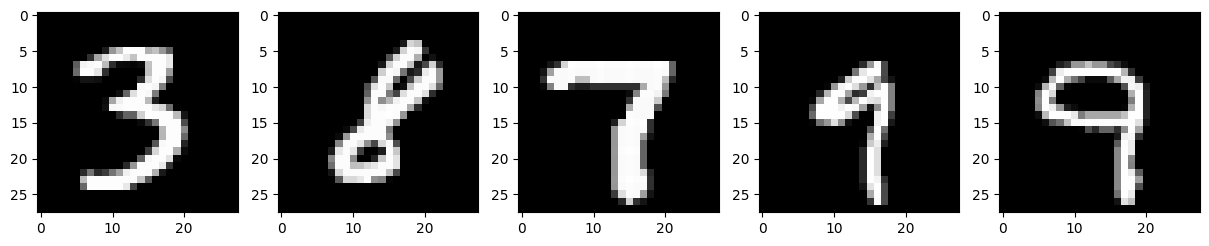

In [7]:
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+ 1)
    plt.axis(True)
    plt.imshow(X_train[i], cmap = "gray")
    plt.subplots_adjust(wspace = 0.2, hspace=0.2)

In [8]:
X_train = X_train.reshape((X_train.shape[0], 28 * 28)).astype("float32")/255
X_test = X_test.reshape((X_test.shape[0], 28*28)).astype("float32")/255
X_valid = X_valid.reshape((X_valid.shape[0], 28* 28)).astype("float32")/255

##### Integer label encoding 
integer label encoding mainly focuses on when the class labels have relationship to one another 

e.g for the fashion_mnist data set the class labels are mapped to integer labels

    0 T-shirt/top
    1 Trouser
    2 Pullover
    3 Dress
    4 Coat
    5 Sandal
    6 Shirt
    7 Sneaker
    8 Bag
    9 Ankle boot

In [9]:
((X_train_fashion, y_train_fashion), (_,_)) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
y_train_fashion[:9]

array([9, 0, 0, 3, 0, 2, 7, 2, 5], dtype=uint8)

#### One Hot Encoding

this encoding method basically represent each class label as binary vector adnwe can use this encoding method when the class labels are not related to eachother

In [ ]:
y_train_onehot = to_categorical(y_train_fashion[:9])

In [ ]:
y_train_onehot

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]])

In [ ]:
y_train = to_categorical(y_train)
y_valid = to_categorical(y_valid)
y_test = to_categorical(y_test)

##### Why we use one-hot Encoding?

we coverted the above data to **one-hot** because the labes for the output in MNIST dataset are *catagories* (digits `0` through `9`).

If we kept them as normal integers, the neural network might mistakenly treat these classes as numerical values (e.g. thinking an `8` is "greater" than a `4`), which drectly messes up the output.

Instead, we format the labels so the model compares predictions aross **10 distnict classes** equally.
 
**Example**
if we want to predict the diit `3` our target output array becomes:
`[0,0,0,1,0,0,0,0,0,0]`

### Model implementation


In [15]:
model = tf.keras.Sequential()

model.add(Dense(128, activation="relu", input_shape = (X_train.shape[1],)))
model.add(Dense(128, activation = "relu"))
model.add(Dense(10, activation = "softmax"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile the model

This step defines the optimizer and loss function tha will be used itnthe training loop

In [19]:
model.compile(optimizer="rmsprop",
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])

#### Train Model

In [20]:
training_results = model.fit (X_train, 
                              y_train,
                              epochs = 20,
                              batch_size = 64,
                              validation_data = (X_valid, y_valid));

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8618 - loss: 0.4816 - val_accuracy: 0.9429 - val_loss: 0.1782
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9606 - loss: 0.1286 - val_accuracy: 0.9625 - val_loss: 0.1234
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9747 - loss: 0.0831 - val_accuracy: 0.9670 - val_loss: 0.1174
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9823 - loss: 0.0612 - val_accuracy: 0.9686 - val_loss: 0.1149
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9871 - loss: 0.0467 - val_accuracy: 0.9709 - val_loss: 0.1197
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9897 - loss: 0.0363 - val_accuracy: 0.9723 - val_loss: 0.1158
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9925 - loss: 0.0288 - val_accuracy: 0.9724 - val_loss: 0.1242
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9937 - loss: 0.0231 - val_accuracy: 0.

#### Plot the Training Results

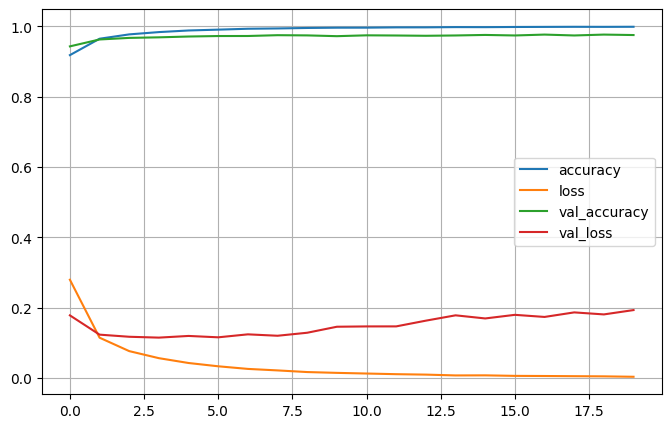

In [ ]:
pd.DataFrame(training_results.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

#### Model Evaluation
Let's make predictions on sample test image

In [31]:
predictions = model.predict(X_test)
print("Ground Truth for test digit: ", y_test[0])
print("\n");
print("Predictions for each class:\n")
for i in range(10):
    print("digit:", i, "Probablity ", predictions[0][i])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Ground Truth for test digit:  [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


Predictions for each class:

digit: 0 Probablity  2.2654945e-26
digit: 1 Probablity  2.5347896e-23
digit: 2 Probablity  4.4071237e-24
digit: 3 Probablity  2.129067e-15
digit: 4 Probablity  2.7746485e-28
digit: 5 Probablity  1.7343871e-25
digit: 6 Probablity  5.10509e-29
digit: 7 Probablity  1.0
digit: 8 Probablity  3.367911e-26
digit: 9 Probablity  8.699863e-15


#### Confusion Matrics

In [32]:
predicted_labels = [np.argmax(i) for i in predictions]

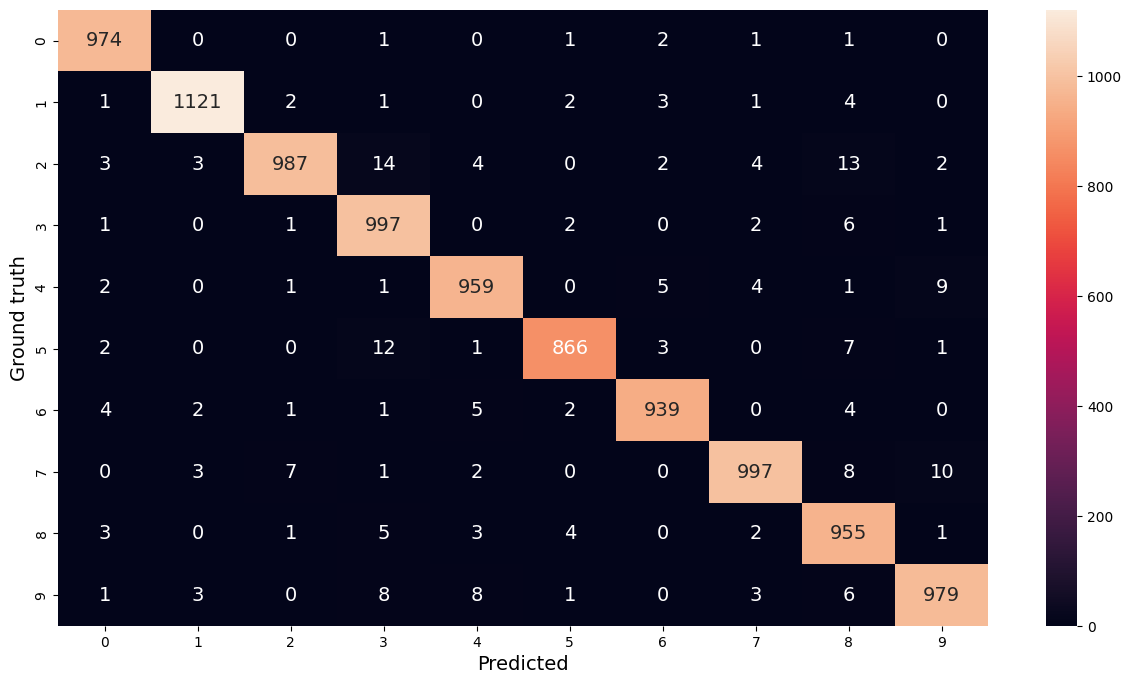

In [34]:
#lets convert the one hot encoded labels to integers.
y_test_integer_labels = tf.argmax(y_test, axis = 1)

confusion_mat = tf.math.confusion_matrix(labels = y_test_integer_labels, predictions = predicted_labels)

plt.figure(figsize=(15, 8))
import seaborn as sns
sns.heatmap(confusion_mat, annot = True, fmt = "d", annot_kws = {"size" : 14})
plt.xlabel("Predicted")
plt.ylabel("Ground truth")
plt.show()

### Conclusion

In this notebook, we successfully built an end-to-end Deep Learning pipeline using TensorFlow and Keras to classify image data. Here are the key takeaways from our workflow:

1. **Data Preprocessing**: We prepared our image data by flattening the 2D pixel grids into 1D arrays and normalizing the pixel values to a scale of `0` to `1`. We also applied **One-Hot Encoding** to our target labels to ensure our model treats all 10 distinct classes equally.
2. **Model Architecture**: We designed a Multi-Layer Perceptron (MLP) using the Keras `Sequential` API. We used `ReLU` activation for our hidden layers to introduce non-linearity, and a `Softmax` output layer to generate a probability distribution across our 10 classes.
3. **Training & Validation**: We compiled the model using the `rmsprop` optimizer and `categorical_crossentropy` loss. By using a validation dataset during our 20 epochs of training, we could monitor the model's ability to generalize to unseen data and watch for signs of overfitting.
4. **Evaluation**: We visualized our training results using learning curves to see how accuracy and loss improved over time. Finally, we used a **Confusion Matrix** to evaluate our predictions, allowing us to see exactly which numbers our model predicts perfectly and which numbers it occasionally confuses.
